<a href="https://colab.research.google.com/github/areesha-del/google-colab-tasks/blob/main/WEEK_5%2CDAY_(2)_CLASSWORK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INSTALL LIABRARIES**

In [ ]:
!pip install wikipedia-api gensim scikit-learn nltk matplotlib seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.2 MB/s eta 0:00:00
  Created wheel for wikipedia-api: filename=Wikipedia_API-0.9.0-py3-none-any.whl size=15422 sha256=3db8c863b2a76ef0221d7850eef99681aa48f67b3a1d1189bfc21a4584e9a9f8
  Stored in directory: /root/.cache/pip/wheels/08/22/bd/5181c75f59d48538eb0c0f3246ac541b8a3f0bce3bfd097047
Successfully built wikipedia-api


**Part A – Dataset Preparation using API (Wikipedia)**

In [ ]:
# Install if needed
# !pip install wikipedia-api pandas

import wikipediaapi
import pandas as pd

# Create Wikipedia object with proper user agent
wiki = wikipediaapi.Wikipedia(
    language='en',
    user_agent='NLP_Word2Vec_Class_Project'
)

# Define categories and topics (25 per category = 100 total)
categories = {
    "education": [
        "Education", "Teacher", "School", "University", "Student",
        "Learning", "Curriculum", "Classroom", "Higher education",
        "Online education", "Educational technology", "Distance education",
        "Primary education", "Secondary education", "Academic degree",
        "Examination", "Scholarship", "Educational psychology",
        "Special education", "Vocational education", "Literacy",
        "STEM education", "Pedagogy", "Homework", "Boarding school"
    ],

    "health": [
        "Health", "Hospital", "Doctor", "Medicine", "Nursing",
        "Public health", "Mental health", "Nutrition", "Disease",
        "Surgery", "Pharmacy", "Vaccination", "Cancer",
        "Cardiology", "Diabetes", "Epidemiology", "Anatomy",
        "Physiology", "Healthcare system", "Emergency medicine",
        "Infectious disease", "Medical diagnosis", "Therapy",
        "Biomedical research", "Health insurance"
    ],

    "sports": [
        "Sports", "Football", "Cricket", "Basketball", "Tennis",
        "Olympic Games", "Athlete", "Swimming", "Volleyball",
        "Hockey", "Baseball", "Rugby", "Golf",
        "Badminton", "Table tennis", "Boxing", "Wrestling",
        "Gymnastics", "Cycling", "Marathon",
        "Skating", "Skiing", "Surfing", "Karate", "Taekwondo"
    ],

    "technology": [
        "Technology", "Computer", "Artificial intelligence",
        "Software", "Internet", "Machine learning",
        "Data science", "Cybersecurity", "Robotics",
        "Blockchain", "Cloud computing", "Programming language",
        "Operating system", "Database", "Computer network",
        "Big data", "Quantum computing", "Virtual reality",
        "Augmented reality", "Semiconductor",
        "Microprocessor", "Automation", "Web development",
        "Mobile application", "Information technology"
    ]
}

# Collect data
data = []

for category, topics in categories.items():
    for topic in topics:
        page = wiki.page(topic)
        if page.exists():
            data.append({
                "title": topic,
                "category": category,
                "text": page.summary
            })
        else:
            print(f"Page not found: {topic}")

# Create DataFrame
df = pd.DataFrame(data)

# Save to CSV
df.to_csv("wiki_dataset.csv", index=False)

# Show results
print("✅ Dataset created successfully!")
print("Dataset Shape:", df.shape)

print("\nCategory Distribution:")
print(df["category"].value_counts())

print("\nSample Data:")
print(df.head())

✅ Dataset created successfully!
Dataset Shape: (100, 3)

Category Distribution:
category
education     25
health        25
sports        25
technology    25
Name: count, dtype: int64

Sample Data:
        title   category                                               text
0   Education  education  Education is the transmission of knowledge and...
1     Teacher  education  A teacher, also called a schoolteacher or form...
2      School  education  A school is an educational institution (and, i...
3  University  education  A university (from Latin  universitas 'a whole...
4     Student  education  A student is a person enrolled in a school or ...


**Part B – Preprocessing**

In [ ]:
import nltk
import re
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) >= 2]
    return tokens

# Show before/after examples
for i in range(3):
    print("\nOriginal:\n", df["text"][i][:200])
    print("\nProcessed:\n", preprocess(df["text"][i])[:20])

df["tokens"] = df["text"].apply(preprocess)


Original:
 Education is the transmission of knowledge and skills and the development of character traits. Formal education happens in a complex institutional framework, like public schools. Non-formal education 

Processed:
 ['education', 'transmission', 'knowledge', 'skills', 'development', 'character', 'traits', 'formal', 'education', 'happens', 'complex', 'institutional', 'framework', 'like', 'public', 'schools', 'nonformal', 'education', 'also', 'structured']

Original:
 A teacher, also called a schoolteacher or formally an educator, is a person who helps students to acquire knowledge, competence, or virtue, via the practice of teaching.
Informally the role of teacher

Processed:
 ['teacher', 'also', 'called', 'schoolteacher', 'formally', 'educator', 'person', 'helps', 'students', 'acquire', 'knowledge', 'competence', 'virtue', 'via', 'practice', 'teaching', 'informally', 'role', 'teacher', 'may']

Original:
 A school is an educational institution (and, in the case of in-person le

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Part C – Train Word2Vec**

In [ ]:
from gensim.models import Word2Vec
import time

sentences = df["tokens"].tolist()

# CBOW
start = time.time()
cbow_model = Word2Vec(sentences=sentences,
                      vector_size=100,
                      window=5,
                      min_count=2,
                      sg=0)
print("CBOW training time:", time.time() - start)

# Skip-gram
start = time.time()
sg_model = Word2Vec(sentences=sentences,
                    vector_size=100,
                    window=5,
                    min_count=2,
                    sg=1)
print("Skip-gram training time:", time.time() - start)

# Save models
cbow_model.save("cbow_model.model")
sg_model.save("skipgram_model.model")

CBOW training time: 0.16127800941467285
Skip-gram training time: 0.7044551372528076


**Part D – Embedding Experiments**

In [ ]:
keywords = ["teacher", "school", "hospital", "computer", "football"]

for word in keywords:
    if word in cbow_model.wv:
        print(f"\nTop similar to '{word}':")
        print(cbow_model.wv.most_similar(word, topn=10))


Top similar to 'teacher':
[('main', 0.4202987253665924), ('diabetes', 0.41214558482170105), ('games', 0.41118815541267395), ('modern', 0.3801645040512085), ('usually', 0.37573352456092834), ('data', 0.3737105429172516), ('disease', 0.3734093904495239), ('cricket', 0.37251001596450806), ('world', 0.3722427189350128), ('ball', 0.3698391318321228)]

Top similar to 'school':
[('education', 0.8217981457710266), ('used', 0.812999427318573), ('games', 0.7998655438423157), ('health', 0.7993696331977844), ('ball', 0.7963564395904541), ('world', 0.7944139242172241), ('one', 0.79348224401474), ('many', 0.7902685403823853), ('data', 0.7840489149093628), ('information', 0.7821056842803955)]

Top similar to 'hospital':
[('learning', 0.4834330081939697), ('called', 0.4809407591819763), ('physical', 0.48081669211387634), ('techniques', 0.4800914227962494), ('million', 0.47761407494544983), ('team', 0.4727594256401062), ('often', 0.4715244472026825), ('disease', 0.4683939218521118), ('physically', 0.4

**Analogy Tests**

In [ ]:
# Education analogy
print(cbow_model.wv.most_similar(
    positive=["teacher", "student"],
    negative=["school"],
    topn=5
))

# Health analogy
print(cbow_model.wv.most_similar(
    positive=["doctor", "hospital"],
    negative=["patient"],
    topn=5
))

[('touches', 0.2954246401786804), ('citizens', 0.2711368799209595), ('virus', 0.26603028178215027), ('little', 0.25910481810569763), ('therapists', 0.24022506177425385)]
[('techniques', 0.3786243498325348), ('control', 0.3676462471485138), ('gradually', 0.3628740608692169), ('cricket', 0.3402183949947357), ('million', 0.3401680588722229)]


**Visualize 50 Words using PCA**

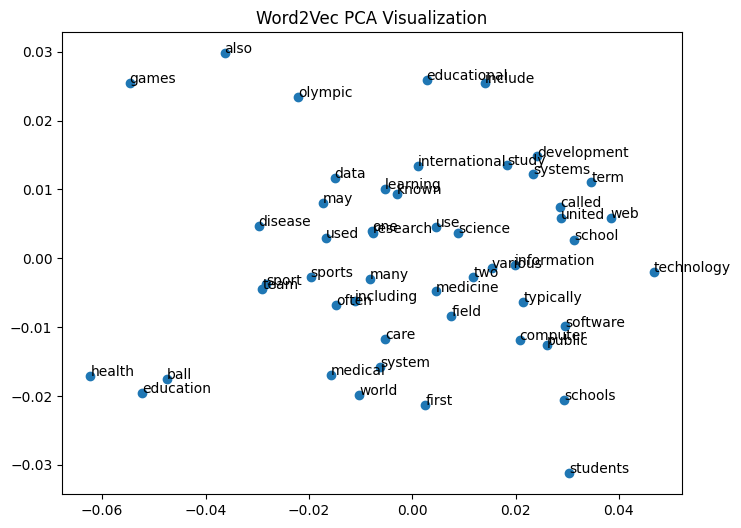

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

words = list(cbow_model.wv.index_to_key)[:50]
vectors = np.array([cbow_model.wv[word] for word in words])

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
plt.scatter(result[:,0], result[:,1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i,0], result[i,1]))

plt.title("Word2Vec PCA Visualization")
plt.show()

**Part E – Simple Classification (Document Embeddings)**

In [ ]:
import numpy as np

def document_vector(model, tokens):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

df["doc_vector"] = df["tokens"].apply(lambda x: document_vector(cbow_model, x))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = np.vstack(df["doc_vector"].values)
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   education       0.00      0.00      0.00         6
      health       0.00      0.00      0.00         6
      sports       0.15      1.00      0.26         3
  technology       0.00      0.00      0.00         5

    accuracy                           0.15        20
   macro avg       0.04      0.25      0.07        20
weighted avg       0.02      0.15      0.04        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**CONFUSION MATRIX**

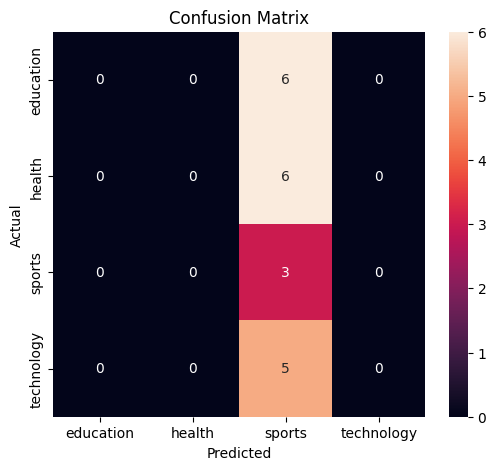

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=clf.classes_,
            yticklabels=clf.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()